Using image: c:\Users\beyza.ayguen\Desktop\tamproject\train\tomo_00e047\slice_0169.jpg


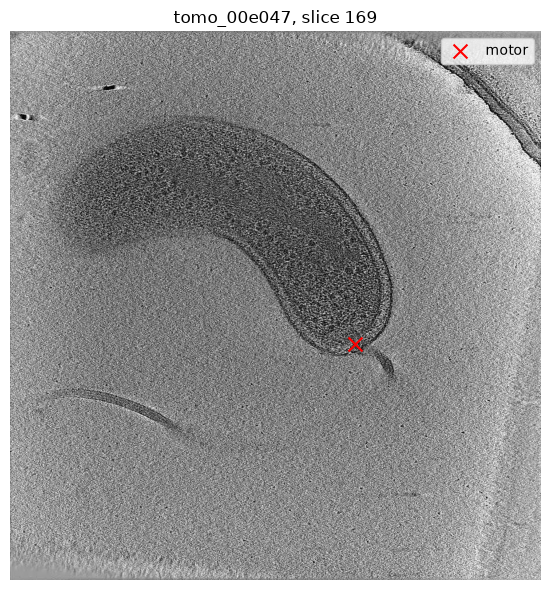

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

BASE_DIR = os.getcwd()  # folder with train/, train_labels.csv
CSV_PATH = os.path.join(BASE_DIR, "train_labels.csv")
TOMO_ID = "tomo_00e047"
TOMO_DIR = os.path.join(BASE_DIR, "train", TOMO_ID)

df = pd.read_csv(CSV_PATH)

# rows for this tomogram that actually have a motor
df_tomo = df[(df["tomo_id"] == TOMO_ID) & (df["Number of motors"] > 0)]
if df_tomo.empty:
    raise ValueError(f"No motor rows for {TOMO_ID}")

# find a row whose slice exists on disk 
img_path = None
row_used = None
for _, row in df_tomo.iterrows():
    z = int(row["Motor axis 0"])
    candidate = os.path.join(TOMO_DIR, f"slice_{z:04d}.jpg")
    if os.path.exists(candidate):
        img_path = candidate
        row_used = row
        break

if img_path is None:
    raise FileNotFoundError("No matching slice_XXXX.jpg found for this tomo")

print("Using image:", img_path)

# Get motor coordinates
z = int(row_used["Motor axis 0"])
y = int(row_used["Motor axis 1"])  # row (y)
x = int(row_used["Motor axis 2"])  # column (x)

# Load and normalize image 
img = np.array(Image.open(img_path).convert("L"), dtype=np.float32)

low, high = np.percentile(img, 0.5), np.percentile(img, 99.5)
img_norm = np.clip((img - low) / (high - low + 1e-8), 0, 1)

#  Show slice with motor mark 
plt.figure(figsize=(6, 6))
plt.imshow(img_norm, cmap="gray")
plt.scatter(x, y, s=100, c="red", marker="x", label="motor")
plt.title(f"{TOMO_ID}, slice {z}")
plt.legend()
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np

BASE_DIR = os.getcwd()                 # folder with train_labels.csv
CSV_PATH = os.path.join(BASE_DIR, "train_labels.csv")

df = pd.read_csv(CSV_PATH)

print("Columns:", list(df.columns))
print("\nFirst rows:")
print(df.head())

# Basic info about tomograms 
# One line per tomo_id: how many motors, how many rows
tomo_stats = (
    df.groupby("tomo_id")
      .agg(
          n_rows=("Motor axis 0", "count"),
          n_motors=("Number of motors", "max")
      )
      .reset_index()
)

print("\nPer-tomogram stats (first 10):")
print(tomo_stats.head(10))

#  Example: a tomogram with at least one motor 
pos_rows = df[df["Number of motors"] > 0]
if not pos_rows.empty:
    ex = pos_rows.iloc[0]

    z = int(ex["Motor axis 0"])
    y = int(ex["Motor axis 1"])
    x = int(ex["Motor axis 2"])

    sz = int(ex["Array shape (axis 0)"])
    sy = int(ex["Array shape (axis 1)"])
    sx = int(ex["Array shape (axis 2)"])

    print("\nExample with a motor:")
    print("tomo_id:", ex["tomo_id"])
    print(f"coords (z, y, x) = ({z}, {y}, {x})")
    print(f"array shape      = ({sz}, {sy}, {sx})")

    # check that coordinates are inside the volume
    inside = (0 <= z < sz) and (0 <= y < sy) and (0 <= x < sx)
    print("coords inside array shape?", inside)

# --- Example: a tomogram with no motor (negative) ---
neg_rows = df[df["Number of motors"] == 0]
if not neg_rows.empty:
    ex_neg = neg_rows.iloc[0]
    print("\nExample with NO motor:")
    print("tomo_id:", ex_neg["tomo_id"])
    print(
        "coords (z, y, x) =",
        int(ex_neg["Motor axis 0"]),
        int(ex_neg["Motor axis 1"]),
        int(ex_neg["Motor axis 2"]),
    )
    print("Number of motors:", int(ex_neg["Number of motors"]))

Columns: ['row_id', 'tomo_id', 'Motor axis 0', 'Motor axis 1', 'Motor axis 2', 'Array shape (axis 0)', 'Array shape (axis 1)', 'Array shape (axis 2)', 'Voxel spacing', 'Number of motors']

First rows:
   row_id      tomo_id  Motor axis 0  Motor axis 1  Motor axis 2  \
0       0  tomo_003acc          -1.0          -1.0          -1.0   
1       1  tomo_00e047         169.0         546.0         603.0   
2       2  tomo_00e463         235.0         403.0         137.0   
3       3  tomo_00e463         243.0         363.0         153.0   
4       4  tomo_00e463         222.0         379.0         144.0   

   Array shape (axis 0)  Array shape (axis 1)  Array shape (axis 2)  \
0                   500                  1912                  1847   
1                   300                   959                   928   
2                   500                   924                   956   
3                   500                   924                   956   
4                   500            

In [14]:
import os
import numpy as np
import pandas as pd

# --- Paths ---
BASE_DIR = os.getcwd()          # folder with train_labels.csv
CSV_PATH = os.path.join(BASE_DIR, "train_labels.csv")

VAL_FRACTION = 0.2              # ~20% validation
RANDOM_SEED = 42                # keep split fixed

# --- Read labels ---
df = pd.read_csv(CSV_PATH)

# --- Unique tomo_ids ---
tomo_ids = np.array(sorted(df["tomo_id"].unique()))
print("Total tomograms:", len(tomo_ids))

# --- Random train/val split by tomo_id ---
rng = np.random.default_rng(RANDOM_SEED)
perm = rng.permutation(len(tomo_ids))

val_size = max(1, int(len(tomo_ids) * VAL_FRACTION))
val_ids = tomo_ids[perm[:val_size]]
train_ids = tomo_ids[perm[val_size:]]

print("Train tomograms:", len(train_ids))
print("Val tomograms  :", len(val_ids))

print("\nExample train IDs:", train_ids[:5])
print("Example val IDs  :", val_ids[:5])

# --- Save ID lists to text files ---
train_file = os.path.join(BASE_DIR, "train_ids.txt")
val_file = os.path.join(BASE_DIR, "val_ids.txt")

with open(train_file, "w") as f:
    for t in train_ids:
        f.write(f"{t}\n")

with open(val_file, "w") as f:
    for t in val_ids:
        f.write(f"{t}\n")

print(f"\nSaved: {train_file}")
print(f"Saved: {val_file}")

# --- Sanity checks ---
assert set(train_ids).isdisjoint(val_ids)
assert set(train_ids) | set(val_ids) == set(tomo_ids)

Total tomograms: 648
Train tomograms: 519
Val tomograms  : 129

Example train IDs: ['tomo_8c13d9' 'tomo_6a6a3b' 'tomo_2f3261' 'tomo_646049' 'tomo_b93a2d']
Example val IDs  : ['tomo_d3bef7' 'tomo_518a1f' 'tomo_cc2b5c' 'tomo_cabaa0' 'tomo_4b124b']

Saved: c:\Users\beyza.ayguen\Desktop\tamproject\train_ids.txt
Saved: c:\Users\beyza.ayguen\Desktop\tamproject\val_ids.txt


torch not found, installing...
torch installed.
Total samples with existing slice: 1
Dataset size: 1


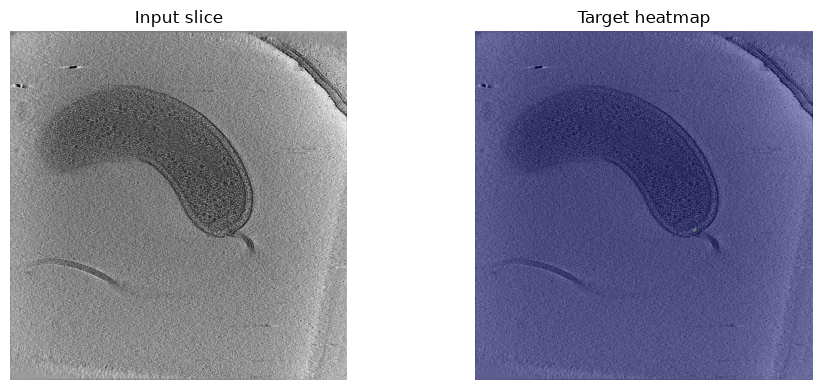

In [16]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# ---- Try to import torch, install if missing ----
try:
    import torch
    from torch.utils.data import Dataset
except ModuleNotFoundError:
    import sys, subprocess
    print("torch not found, installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch"])
    import torch
    from torch.utils.data import Dataset
    print("torch installed.")


# ---------- Paths ----------
BASE_DIR = os.getcwd()                     # folder with train/, train_labels.csv
CSV_PATH = os.path.join(BASE_DIR, "train_labels.csv")
TRAIN_DIR = os.path.join(BASE_DIR, "train")

SIGMA = 3.0                                # Gaussian sigma in pixels


# ---------- Utilities ----------
def load_and_normalize(path):
    """Load grayscale jpg and normalize using 0.5/99.5 percentiles."""
    img = np.array(Image.open(path).convert("L"), dtype=np.float32)
    low, high = np.percentile(img, 0.5), np.percentile(img, 99.5)
    img = np.clip((img - low) / (high - low + 1e-8), 0, 1)
    return img  # (H, W) in [0,1]


def make_gaussian_heatmap(h, w, y, x, sigma=3.0):
    """Return (H, W) heatmap with a 2D Gaussian peak at (y, x)."""
    yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    dist2 = (yy - y) ** 2 + (xx - x) ** 2
    heatmap = np.exp(-dist2 / (2 * sigma ** 2)).astype(np.float32)
    return heatmap  # (H, W)


# ---------- Build list of samples from CSV ----------
df = pd.read_csv(CSV_PATH)

samples = []  # each item: (image_path, y, x)

for _, row in df.iterrows():
    if row["Number of motors"] <= 0:
        continue  # skip rows with no motor

    tomo_id = row["tomo_id"]
    z = int(row["Motor axis 0"])
    y = int(row["Motor axis 1"])
    x = int(row["Motor axis 2"])

    tomo_dir = os.path.join(TRAIN_DIR, tomo_id)
    img_path = os.path.join(tomo_dir, f"slice_{z:04d}.jpg")

    if os.path.exists(img_path):
        samples.append((img_path, y, x))

print(f"Total samples with existing slice: {len(samples)}")
if len(samples) == 0:
    raise RuntimeError("No (image, motor) pairs found on disk.")


# ---------- PyTorch Dataset ----------
class MotorSliceDataset(Dataset):
    """2D dataset: (normalized slice, Gaussian heatmap)."""

    def __init__(self, samples, sigma=3.0):
        self.samples = samples
        self.sigma = sigma

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, y, x = self.samples[idx]

        img = load_and_normalize(img_path)         # (H, W)
        h, w = img.shape

        # clamp coordinates to image bounds
        y_clamp = int(np.clip(y, 0, h - 1))
        x_clamp = int(np.clip(x, 0, w - 1))

        heatmap = make_gaussian_heatmap(h, w, y_clamp, x_clamp, self.sigma)

        # add channel dim and convert to tensors
        img_t = torch.from_numpy(img).unsqueeze(0)       # (1, H, W)
        heatmap_t = torch.from_numpy(heatmap).unsqueeze(0)  # (1, H, W)

        return img_t, heatmap_t


dataset = MotorSliceDataset(samples, sigma=SIGMA)
print("Dataset size:", len(dataset))


# ---------- Quick visual check ----------
img_t, hm_t = dataset[0]
img = img_t.squeeze(0).numpy()
heatmap = hm_t.squeeze(0).numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Input slice")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Target heatmap")
plt.imshow(img, cmap="gray")
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.axis("off")

plt.tight_layout()
plt.show()

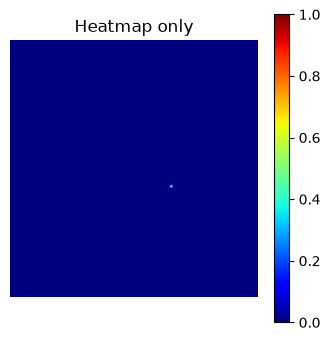

max value: 1.0


In [18]:
plt.figure(figsize=(4, 4))
plt.title("Heatmap only")
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.axis("off")
plt.show()

print("max value:", heatmap.max())